In [13]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [14]:
# ================================
# CORE LIBRARIES
# ================================

import importlib
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from mlxtend.frequent_patterns import fpgrowth, association_rules

# ================================
# PROJECT PATHS AND LOCAL MODULES
# ================================

def bootstrap_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "Code").exists() and (candidate / "Data").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root containing both 'Code' and 'Data'."
    )

PROJECT_ROOT = bootstrap_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import las_bambas_analysis.cluster_plots as cluster_plots_module
import las_bambas_analysis.paths as paths_module

cluster_plots_module = importlib.reload(cluster_plots_module)
paths_module = importlib.reload(paths_module)

DEFAULT_CLUSTER_COLORS = cluster_plots_module.DEFAULT_CLUSTER_COLORS
DEFAULT_CLUSTER_EDGE = cluster_plots_module.DEFAULT_CLUSTER_EDGE
DEFAULT_CLUSTER_MARKERS = cluster_plots_module.DEFAULT_CLUSTER_MARKERS
plot_cluster_points = cluster_plots_module.plot_cluster_points
plot_cluster_time = cluster_plots_module.plot_cluster_time
prepare_period = cluster_plots_module.prepare_period
build_project_paths = paths_module.build_project_paths
ensure_output_directories = paths_module.ensure_output_directories

project_paths = ensure_output_directories(build_project_paths(PROJECT_ROOT))
DATA_DIR = project_paths.data_dir
RESULTS_DIR = project_paths.results_dir
CLUSTER_OUTPUT_DIR = project_paths.cluster.output_dir
CLUSTER_FIGURES_DIR = project_paths.cluster.figures_dir
CLUSTER_MAPS_DIR = project_paths.cluster.maps_dir
CLUSTER_TEMPORAL_MAPS_DIR = project_paths.cluster.temporal_maps_dir

RUTA_CONFLICTO = project_paths.conflict_matrix_path
RUTA_REPORTE_CONFLICTOS = project_paths.conflict_report_path
RUTA_GPKG = project_paths.gpkg_path

CLUSTER_COLORS = DEFAULT_CLUSTER_COLORS.copy()
CLUSTER_EDGE = DEFAULT_CLUSTER_EDGE.copy()
CLUSTER_MARKERS = DEFAULT_CLUSTER_MARKERS.copy()

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\Rofer\Proyectos\las-bambas-conflict-analysis


# **FILE INPUTS**

In [15]:
conflicto = pd.read_csv(RUTA_CONFLICTO, index_col=0)

In [16]:
conflicto.columns

Index(['Grupo', 'EsIlegal', 'EsInformal', 'PrimeraFecha_min',
       'UltimaFecha_max', 'GrupoID', 'Departamento', 'Tipo', 'Caso', 'Actores',
       'Actores primarios', 'Actores secundarios', 'Actores terciarios',
       'Pollution and Environmental Damage', 'Material Transport Issues',
       'Community-Mine Disputes', 'Resource Competition',
       'Displacement and Relocation', 'Illegal/Informal Mining',
       'Unfulfilled Company Commitments', 'Poor Public Works Execution',
       'Decisions Without Community Consent',
       'Exclusion from EIA Impact Area'],
      dtype='object')

In [17]:
gruposid=conflicto.Grupo

In [18]:
X=conflicto[['Pollution and Environmental Damage', 'Material Transport Issues',
       'Community-Mine Disputes', 'Resource Competition',
       'Displacement and Relocation', 'Illegal/Informal Mining',
       'Unfulfilled Company Commitments', 'Poor Public Works Execution',
       'Decisions Without Community Consent',
       'Exclusion from EIA Impact Area']]

We have the root-cause matrix in one-hot encoding. Extended definitions of the root causes can be found in `metadata.csv`

In [21]:
X

,Pollution and Environmental Damage,Material Transport Issues,Community-Mine Disputes,Resource Competition,Displacement and Relocation,Illegal/Informal Mining,Unfulfilled Company Commitments,Poor Public Works Execution,Decisions Without Community Consent,Exclusion from EIA Impact Area
0,0,0,0,0,0,0,1,0,0,0
1,0,1,1,1,1,0,1,0,0,0
2,1,0,0,0,0,1,1,0,0,0
3,0,0,0,1,0,0,1,0,0,0
4,1,1,0,0,0,0,1,0,1,0
5,1,1,0,0,0,0,1,0,0,1
6,0,1,0,0,0,0,1,1,0,1
7,1,1,0,0,0,0,0,0,0,0
8,0,1,1,0,0,0,1,0,1,0
9,0,0,1,0,0,1,0,0,1,0


# **CLUSTERS**

## **METHOD COMPARISON**

Jaccard dissimilarity was computed from the binary matrix. K-medoids and hierarchical clustering were then applied to the resulting distance matrix, while DBSCAN was run on the binary matrix using the Jaccard metric. Finally, the agreement between the resulting clusterings was assessed through pairwise comparisons using the Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI).

In [22]:
# =========================
# MATRIZ BINARIA FINAL
# =========================
# Distancia Jaccard
D = squareform(pdist(X, metric='jaccard'))
D_condensed = pdist(X, metric='jaccard')

# =========================
# 1) K-MEDOIDS + JACCARD
# =========================
def kmedoids(D, k, max_iter=100, random_state=42):
    np.random.seed(random_state)
    m = D.shape[0]
    medoids = np.random.choice(m, k, replace=False)

    for _ in range(max_iter):
        labels = np.argmin(D[:, medoids], axis=1)
        new_medoids = np.copy(medoids)

        for i in range(k):
            cluster_points = np.where(labels == i)[0]
            if len(cluster_points) == 0:
                continue
            costs = np.sum(D[np.ix_(cluster_points, cluster_points)], axis=1)
            new_medoids[i] = cluster_points[np.argmin(costs)]

        if np.all(medoids == new_medoids):
            break
        medoids = new_medoids

    labels = np.argmin(D[:, medoids], axis=1)
    return labels, medoids

labels_kmedoids, medoids = kmedoids(D, k=3)

# =========================
# 2) HIERARCHICAL + JACCARD + AVERAGE
# =========================
Z = linkage(D_condensed, method='average')
labels_hier = fcluster(Z, 3, criterion='maxclust')

# fcluster returns 1, 2, 3; optionally we remap it to 0, 1, 2
labels_hier = labels_hier - 1

# =========================
# 3) DBSCAN + JACCARD
# =========================
labels_dbscan = DBSCAN(eps=0.45, min_samples=3, metric='jaccard').fit_predict(X)

# =========================
# COMPARISON FUNCTION
# =========================
def compare_labels(a, b, name_a, name_b, drop_noise=False):
    a = np.array(a)
    b = np.array(b)

    if drop_noise:
        mask = (a != -1) & (b != -1)
        a = a[mask]
        b = b[mask]

    return {
        "Comparison": f"{name_a} vs {name_b}",
        "Observations": len(a),
        "ARI": adjusted_rand_score(a, b),
        "NMI": normalized_mutual_info_score(a, b)
    }

# =========================
# RESULT TABLES
# =========================
results = [
    compare_labels(labels_kmedoids, labels_hier, "K-medoids", "Hierarchical", drop_noise=False),
    compare_labels(labels_kmedoids, labels_dbscan, "K-medoids", "DBSCAN (all)", drop_noise=False),
    compare_labels(labels_hier, labels_dbscan, "Hierarchical", "DBSCAN (all)", drop_noise=False),
    compare_labels(labels_kmedoids, labels_dbscan, "K-medoids", "DBSCAN (non-noise)", drop_noise=True),
    compare_labels(labels_hier, labels_dbscan, "Hierarchical", "DBSCAN (non-noise)", drop_noise=True),
]

agreement_df = pd.DataFrame(results)
agreement_df["ARI"] = agreement_df["ARI"].round(3)
agreement_df["NMI"] = agreement_df["NMI"].round(3)

print(agreement_df)

noise_n = int(np.sum(labels_dbscan == -1))
noise_pct = round(100 * np.mean(labels_dbscan == -1), 1)

print(f"DBSCAN noise: {noise_n} of {len(labels_dbscan)} conflicts ({noise_pct}%)")

                           Comparison  Observations    ARI    NMI
0           K-medoids vs Hierarchical            23  0.513  0.491
1           K-medoids vs DBSCAN (all)            23  0.156  0.249
2        Hierarchical vs DBSCAN (all)            23  0.218  0.323
3     K-medoids vs DBSCAN (non-noise)            14  0.401  0.487
4  Hierarchical vs DBSCAN (non-noise)            14  0.471  0.477
DBSCAN noise: 9 of 23 conflicts (39.1%)


## **FINAL HIERARCHICAL CLUSTER**

In [76]:
# Step 1: choose the number of clusters
k = 3

# Step 2: fit the hierarchical model
model = AgglomerativeClustering(n_clusters=k, metric='jaccard', linkage='average')
clusters = model.fit_predict(X)

# Step 3: add cluster labels to the DataFrame
conflicto['cluster'] = clusters
# Reorder labels for interpretive clarity
conflicto["cluster"] = conflicto["cluster"].map({0: 3, 1: 1, 2: 2})

In [77]:
conflicto.cluster.value_counts()

cluster
2    12
3     8
1     3
Name: count, dtype: int64

## **CHARACTERIZATION OF THE CLUSTERS**

In [78]:
conflicto.iloc[:,-11:]

,Pollution and Environmental Damage,Material Transport Issues,Community-Mine Disputes,Resource Competition,Displacement and Relocation,Illegal/Informal Mining,Unfulfilled Company Commitments,Poor Public Works Execution,Decisions Without Community Consent,Exclusion from EIA Impact Area,cluster
0,0,0,0,0,0,0,1,0,0,0,3
1,0,1,1,1,1,0,1,0,0,0,2
2,1,0,0,0,0,1,1,0,0,0,3
3,0,0,0,1,0,0,1,0,0,0,3
4,1,1,0,0,0,0,1,0,1,0,2
5,1,1,0,0,0,0,1,0,0,1,2
6,0,1,0,0,0,0,1,1,0,1,2
7,1,1,0,0,0,0,0,0,0,0,2
8,0,1,1,0,0,0,1,0,1,0,2
9,0,0,1,0,0,1,0,0,1,0,1


In [79]:
cluster_summary=conflicto.iloc[:,-11:].groupby('cluster').mean()

The chart shows the characterization of the three clusters according to their root causes. Its purpose is to display the relative frequency of each root cause within the total number of conflicts assigned to each cluster.

In [106]:
cluster_summary_transposed = cluster_summary.T
(
cluster_summary_transposed.style
.background_gradient(
    axis=1,
    cmap='YlOrRd',
    vmin=0,
    vmax=1
)
.format("{:.3f}") 
.set_caption("Cluster Interpretation")
)

cluster,1,2,3
Pollution and Environmental Damage,0.000,0.417,0.375
Material Transport Issues,0.000,1.000,0.000
Community-Mine Disputes,0.667,0.167,0.500
Resource Competition,0.000,0.083,0.125
Displacement and Relocation,0.000,0.083,0.000
Illegal/Informal Mining,0.333,0.000,0.125
Unfulfilled Company Commitments,0.000,0.833,1.000
Poor Public Works Execution,0.000,0.333,0.000
Decisions Without Community Consent,1.000,0.333,0.125
Exclusion from EIA Impact Area,0.000,0.417,0.375


**Cluster 1** stands out for complaints related to territorial disputes with the mine and decisions made without the consent of the surrounding population centers. This may also be linked to the rise of informal or illegal mining.

**Cluster 2** is characterized by material transport issues in all cases. This is directly related to the Southern Mining Corridor. These conflicts are associated with pollution, environmental claims regarding formal inclusion within impact areas, economic grievances, and decisions made without community consent.

**Cluster 3** is mainly characterized by complaints about unmet economic commitments. It tends to have more varied drivers, including pollution, disputes between the mine and communities over natural resources, and exclusion from the environmental impact area.

## **TEMPORAL VISUALIZATION**

In [81]:
import pandas as pd

# 1) Read only the required columns
bambas_temporal = pd.read_csv(
    RUTA_REPORTE_CONFLICTOS,
    usecols=['GrupoID', 'Estado', 'FechaReporte']
)

# 2) Filter active conflicts and create an explicit copy
bambas_temporal_activo = (
    bambas_temporal.loc[bambas_temporal['Estado'].eq('Activo')].copy()
)

# 3) Convert dates correctly
bambas_temporal_activo['FechaReporte'] = pd.to_datetime(
    bambas_temporal_activo['FechaReporte'],
    format='%d/%m/%Y',
    errors='coerce'
)

# 4) Remove invalid dates, extract the year, drop duplicates, and sort
bambas_temporal_activo = (
    bambas_temporal_activo
    .dropna(subset=['FechaReporte'])
    .assign(FechaReporte=lambda df: df['FechaReporte'].dt.year)
    .drop_duplicates()
    .sort_values('FechaReporte')
)

# 5) Yearly time series
serie_temporal = (
    bambas_temporal_activo
    .groupby('FechaReporte')['GrupoID']
    .count()
)

# 6) Fill missing years within the observed range
rango_completo = range(serie_temporal.index.min(), serie_temporal.index.max() + 1)
serie_temporal = serie_temporal.reindex(rango_completo, fill_value=0)

# 7) Exclude unwanted years
anios_excluir = [2005, 2006, 2025]
bambas_temporal_activo = bambas_temporal_activo.loc[
    ~bambas_temporal_activo['FechaReporte'].isin(anios_excluir)
].copy()

# 8) Prepare cluster table for merge
cluster_grupo = (
    conflicto[['cluster', 'Grupo']]
    .rename(columns={'Grupo': 'GrupoID'})
    .copy()
)

# 9) Merge years with clusters
bambas_temporal_activo_cluster = bambas_temporal_activo.merge(
    cluster_grupo,
    on='GrupoID',
    how='left'
)

# 10) Final summary table
cluster_anio = bambas_temporal_activo_cluster[['cluster', 'FechaReporte', 'GrupoID']].copy()

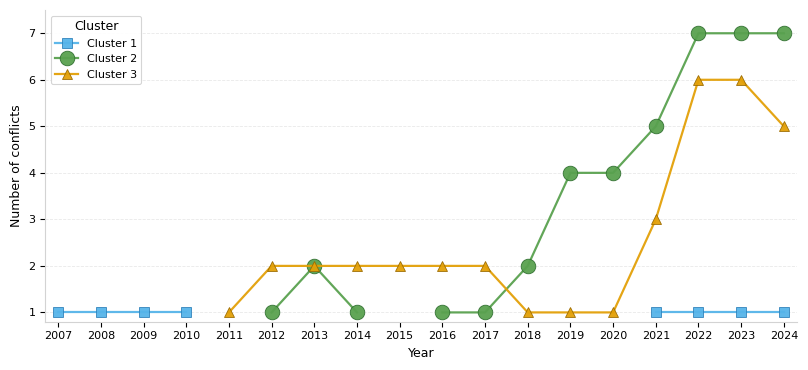

In [82]:
# =========================
# DATA
# =========================
df_grouped = (
    cluster_anio.groupby(['cluster', 'FechaReporte'])['GrupoID']
    .count()
    .reset_index()
)

df_pivot = df_grouped.pivot(index='FechaReporte', columns='cluster', values='GrupoID')
all_years = list(range(2007, 2025))
df_pivot = df_pivot.reindex(all_years, fill_value=0)

for c in [1, 2, 3]:
    if c not in df_pivot.columns:
        df_pivot[c] = 0

df_pivot = df_pivot[[1, 2, 3]]

plot_cluster_time(
    df_pivot=df_pivot,
    output_pdf_path=CLUSTER_FIGURES_DIR / "cluster_time.pdf",
    output_png_path=CLUSTER_FIGURES_DIR / "cluster_time.png",
    show=True,
    add_milestones=False,
    cluster_colors=CLUSTER_COLORS,
    cluster_edge=CLUSTER_EDGE,
    cluster_markers=CLUSTER_MARKERS,
)

## **SPATIAL MAP**

In [83]:
import geopandas as gpd
import folium

In [84]:
ruta = RUTA_GPKG
pueblos = gpd.read_file(ruta, layer='Centros_poblados')

In [85]:
cluster_grupo.rename(columns={'Grupo_ID':'GRUPO_ID'}, inplace=True)
cluster_anio.rename(columns={'GrupoID':'GRUPO_ID'}, inplace=True)

In [86]:
# Merge
cluster_year_population_centers = cluster_anio.merge(pueblos, how='inner', on='GRUPO_ID')

In [87]:
# =========================
# GENERAL CONFIGURATION
# =========================
OUT_DIR = CLUSTER_TEMPORAL_MAPS_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

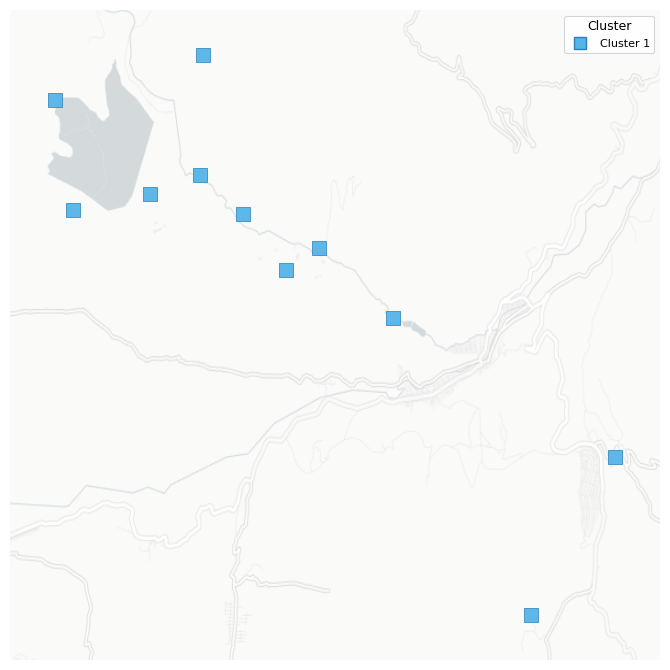

Saved: C:\Users\Rofer\Proyectos\las-bambas-conflict-analysis\Results\cluster_association_rules\maps\clusters_temporales\2007_2010.pdf


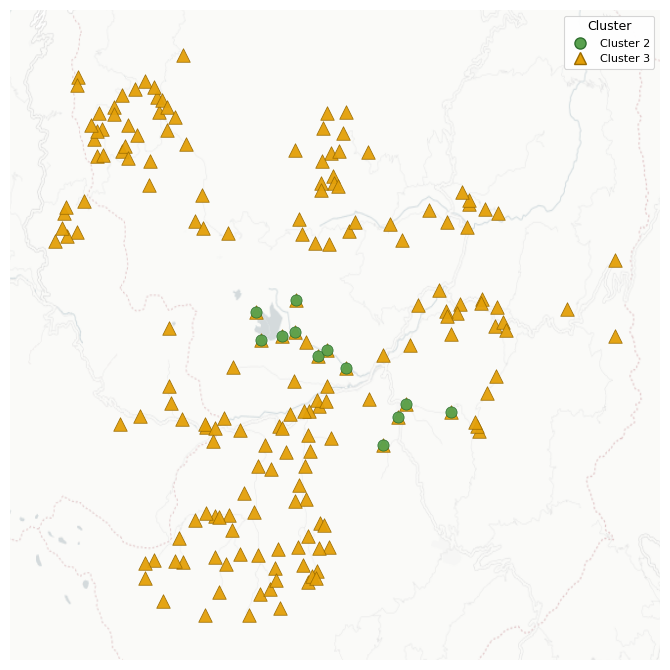

Saved: C:\Users\Rofer\Proyectos\las-bambas-conflict-analysis\Results\cluster_association_rules\maps\clusters_temporales\2011_2012.pdf


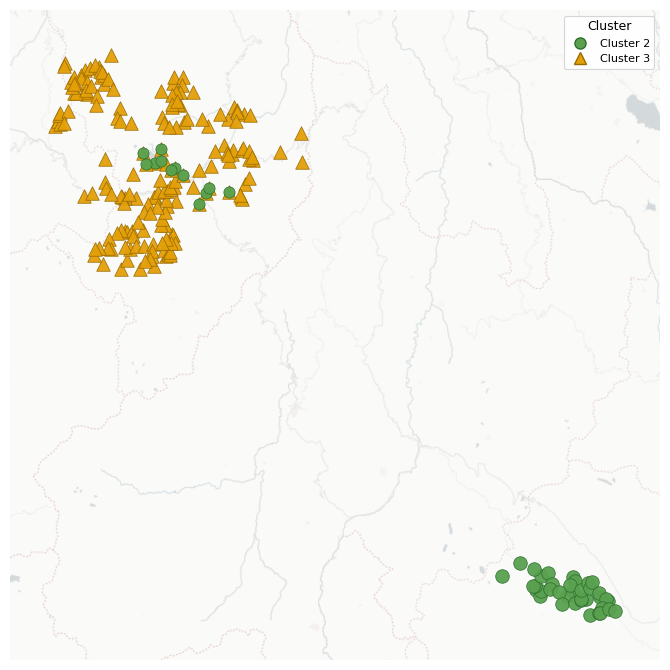

Saved: C:\Users\Rofer\Proyectos\las-bambas-conflict-analysis\Results\cluster_association_rules\maps\clusters_temporales\2013.pdf


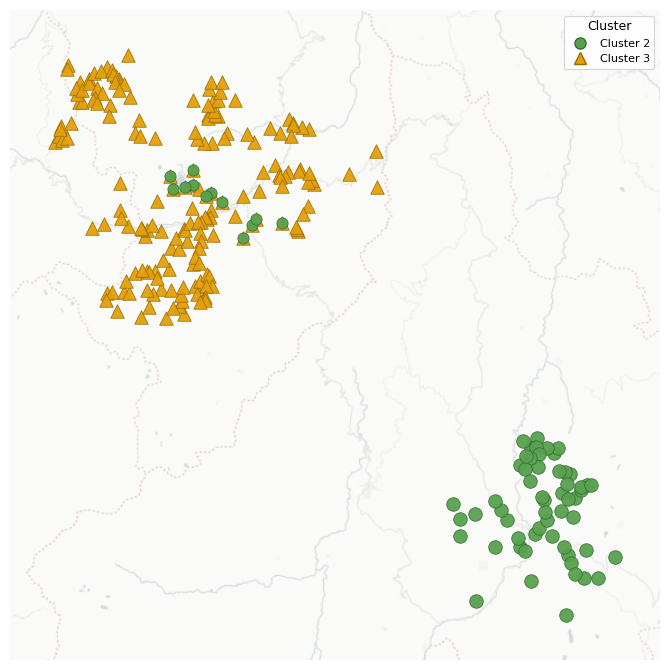

Saved: C:\Users\Rofer\Proyectos\las-bambas-conflict-analysis\Results\cluster_association_rules\maps\clusters_temporales\2014_2018.pdf


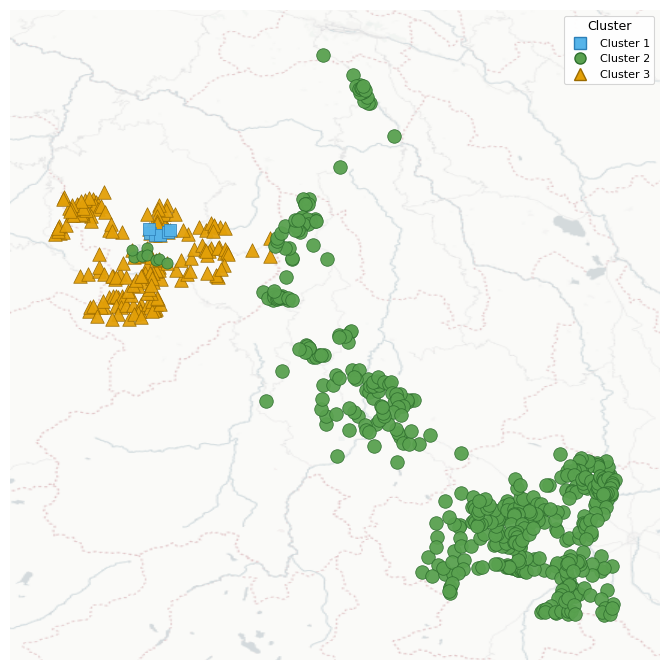

Saved: C:\Users\Rofer\Proyectos\las-bambas-conflict-analysis\Results\cluster_association_rules\maps\clusters_temporales\2019_2024.pdf


In [88]:
pueblos = gpd.read_file(ruta, layer='Centros_poblados')

cluster_grupo = cluster_grupo.rename(columns={'Grupo_ID': 'GRUPO_ID'})
cluster_anio = cluster_anio.rename(columns={'Grupo_ID': 'GRUPO_ID'})

# Merge
cluster_year_population_centers = cluster_anio.merge(pueblos, how='inner', on='GRUPO_ID')
cluster_year_population_centers = gpd.GeoDataFrame(cluster_year_population_centers, geometry='geometry', crs="EPSG:4326")

# =========================
# PERIODS CONSISTENT WITH THE PAPER
# =========================
population_centers_period1 = prepare_period(cluster_year_population_centers, range(2007, 2011))
plot_cluster_points(population_centers_period1, '2007_2010', out_dir=OUT_DIR, show_axes=False, use_basemap=True, show=True, cluster_colors=CLUSTER_COLORS, cluster_edge=CLUSTER_EDGE, cluster_markers=CLUSTER_MARKERS)

population_centers_period2 = prepare_period(cluster_year_population_centers, range(2011, 2013))
plot_cluster_points(population_centers_period2, '2011_2012', out_dir=OUT_DIR, show_axes=False, use_basemap=True, show=True, cluster_colors=CLUSTER_COLORS, cluster_edge=CLUSTER_EDGE, cluster_markers=CLUSTER_MARKERS)

population_centers_period3 = prepare_period(cluster_year_population_centers, [2013])
plot_cluster_points(population_centers_period3, '2013', out_dir=OUT_DIR, show_axes=False, use_basemap=True, show=True, cluster_colors=CLUSTER_COLORS, cluster_edge=CLUSTER_EDGE, cluster_markers=CLUSTER_MARKERS)

population_centers_period4 = prepare_period(cluster_year_population_centers, range(2014, 2019))
plot_cluster_points(population_centers_period4, '2014_2018', out_dir=OUT_DIR, show_axes=False, use_basemap=True, show=True, cluster_colors=CLUSTER_COLORS, cluster_edge=CLUSTER_EDGE, cluster_markers=CLUSTER_MARKERS)

population_centers_period5 = prepare_period(cluster_year_population_centers, range(2019, 2025))
plot_cluster_points(population_centers_period5, '2019_2024', out_dir=OUT_DIR, show_axes=False, use_basemap=True, show=True, cluster_colors=CLUSTER_COLORS, cluster_edge=CLUSTER_EDGE, cluster_markers=CLUSTER_MARKERS)

# **FP-GROWTH**

In [19]:
# =========================
# 1. FP-GROWTH
# =========================
min_support = 0.10
min_confidence = 0.60
min_lift = 1.2

itemsets = fpgrowth(X, min_support=min_support, use_colnames=True)
rules = association_rules(itemsets, metric="confidence", min_threshold=min_confidence)
rules = rules[rules['lift'] >= min_lift].copy()

# =========================
# 2. ELIMINAR REDUNDANCIA
# =========================
rules['total_items'] = rules.apply(
    lambda row: frozenset(row['antecedents'] | row['consequents']),
    axis=1
)

rules = rules.sort_values(by='lift', ascending=False)
rules = rules.drop_duplicates(subset='total_items')

# =========================
# 3. TABLA FINAL
# =========================
rules_final = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
rules_final = rules_final.sort_values(by='lift', ascending=False)

print(rules_final)
print(f"N conflicts used: {X.shape[0]}")
print(f"N causes used: {X.shape[1]}")
print(f"N final rules: {rules_final.shape[0]}")

                                          antecedents  \
17  (Decisions Without Community Consent, Unfulfil...   
6   (Decisions Without Community Consent, Unfulfil...   
28                      (Poor Public Works Execution)   
7   (Material Transport Issues, Decisions Without ...   
24                      (Poor Public Works Execution)   
20  (Decisions Without Community Consent, Unfulfil...   
25                      (Poor Public Works Execution)   

                                          consequents   support  confidence  \
17  (Material Transport Issues, Pollution and Envi...  0.130435        0.60   
6                (Pollution and Environmental Damage)  0.173913        0.80   
28  (Material Transport Issues, Unfulfilled Compan...  0.173913        1.00   
7                (Pollution and Environmental Damage)  0.130435        0.75   
24                        (Material Transport Issues)  0.173913        1.00   
20                        (Material Transport Issues)  0.173913      

c:\Users\Rofer\anaconda3\envs\las-bambas-analysis\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [20]:
# Create a column with the full rule itemset (regardless of order)
rules['total_items'] = rules.apply(lambda row: frozenset(row['antecedents'] | row['consequents']), axis=1)

# Sort by lift (or any preferred metric)
rules = rules.sort_values(by='lift', ascending=False)

# Remove duplicates based on the full itemset
rules = rules.drop_duplicates(subset='total_items')
# === Clear presentation ===
print(f"Top FP-Growth Association Rules (Support ≥ {min_support}, Confidence ≥ {min_confidence}, Lift ≥ {min_lift})")
print("="*70)
for _, row in rules.iterrows():
    antecedents = ', '.join(row['antecedents'])
    consequents = ', '.join(row['consequents'])
    print(f"Rule: {antecedents}  →  {consequents}")
    print(f"Support:    {row['support']:.3f}")
    print(f"Confidence: {row['confidence']:.3f}")
    print(f"Lift:       {row['lift']:.2f}")
    print("-" * 50)

Top FP-Growth Association Rules (Support ≥ 0.1, Confidence ≥ 0.6, Lift ≥ 1.2)
Rule: Decisions Without Community Consent, Unfulfilled Company Commitments  →  Material Transport Issues, Pollution and Environmental Damage
Support:    0.130
Confidence: 0.600
Lift:       2.76
--------------------------------------------------
Rule: Decisions Without Community Consent, Unfulfilled Company Commitments  →  Pollution and Environmental Damage
Support:    0.174
Confidence: 0.800
Lift:       2.30
--------------------------------------------------
Rule: Poor Public Works Execution  →  Material Transport Issues, Unfulfilled Company Commitments
Support:    0.174
Confidence: 1.000
Lift:       2.30
--------------------------------------------------
Rule: Material Transport Issues, Decisions Without Community Consent  →  Pollution and Environmental Damage
Support:    0.130
Confidence: 0.750
Lift:       2.16
--------------------------------------------------
Rule: Poor Public Works Execution  →  Material